<a href="https://colab.research.google.com/github/7235SYXD/Real-Estate/blob/main/DSP_on_Real_Estate_(Notebook_5).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 1 — INSTALL LIBRARIES                                      ║
# ╚══════════════════════════════════════════════════════════════════╝

import subprocess, sys
for lib in ["kagglehub","catboost","shap","optuna",
            "vaderSentiment","yake","textstat"]:
    subprocess.run([sys.executable,"-m","pip","install",lib,"-q"])
print("All libraries installed.")

All libraries installed.


In [2]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 2 — GOOGLE DRIVE                                           ║
# ╚══════════════════════════════════════════════════════════════════╝

import os, shutil
from google.colab import drive, files

drive.mount('/content/drive')
SAVE_DIR = "/content/drive/MyDrive/RealEstate_TXNY"
os.makedirs(SAVE_DIR, exist_ok=True)
print(f"Save directory: {SAVE_DIR}")

Mounted at /content/drive
Save directory: /content/drive/MyDrive/RealEstate_TXNY


In [3]:
# ╔════════════════════════════════════════════════════╗
# ║  CELL 3 — IMPORT ALL LIBRARIES                     ║
# ╚════════════════════════════════════════════════════╝

import os
import re
import warnings
from pathlib import Path
import gc # Import the garbage collection module

import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
from tensorflow.keras import layers as KL

# Sklearn
from sklearn.model_selection import train_test_split, KFold, cross_val_predict, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    roc_auc_score, f1_score, classification_report,
    accuracy_score,
)
from sklearn.linear_model import Ridge as RidgeMeta

# Gradient boosting
!pip install catboost
from catboost import CatBoostRegressor, CatBoostClassifier
import xgboost as xgb

# Deep learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Hyperparameter tuning
!pip install optuna
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Interpretability
import shap

# NLP
!pip install vaderSentiment
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
!pip install yake
import yake
!pip install textstat
import textstat

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:,.4f}".format)

# Set random seeds for reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("=" * 60)
print("All libraries imported successfully.")
print(f"  pandas     : {pd.__version__}")
print(f"  numpy      : {np.__version__}")
print(f"  tensorflow : {tf.__version__}")
print(f"  sklearn    : OK")
print("=" * 60)

All libraries imported successfully.
  pandas     : 2.2.2
  numpy      : 2.0.2
  tensorflow : 2.20.0
  sklearn    : OK


In [4]:
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "dill", "-q"])
import dill, json
import os # Import os module for path checks

CKPT_DIR  = f"{SAVE_DIR}/checkpoints"
CKPT_NAME = "checkpoint_4_to_5"
PKL_FILE_PATH = f"{CKPT_DIR}/{CKPT_NAME}.pkl"
KERAS_JSON_PATH = f"{CKPT_DIR}/{CKPT_NAME}_keras.json"

_state = {} # Initialize _state to an empty dictionary in case of error
_keras_paths = {} # Initialize _keras_paths to an empty dictionary in case of error

print("=" * 65)
print(f"Attempting to restore checkpoint from: {PKL_FILE_PATH}")
print("=" * 65)

if not os.path.exists(PKL_FILE_PATH):
    print(f"ERROR: Checkpoint file '{PKL_FILE_PATH}' not found.")
    print("Please ensure 'Notebook 4' has been run and its state saved successfully to Google Drive.")
    print("Skipping state restoration.")
else:
    try:
        with open(PKL_FILE_PATH, "rb") as f:
            _state = dill.load(f)
        globals().update(_state)
        print(f"CHECKPOINT RESTORED <- {PKL_FILE_PATH}")

        if not os.path.exists(KERAS_JSON_PATH):
            print(f"WARNING: Keras models checkpoint file '{KERAS_JSON_PATH}' not found. Keras models will not be restored.")
        else:
            try:
                with open(KERAS_JSON_PATH) as f:
                    _keras_paths = json.load(f)
                for _name, _path in _keras_paths.items():
                    # Assume 'keras' is available globally from earlier imports (e.g., cell bkVVmwXvBonL)
                    globals()[_name] = keras.models.load_model(_path)
            except Exception as e:
                print(f"WARNING: Failed to load Keras models from '{KERAS_JSON_PATH}': {e}")
                _keras_paths = {} # Clear if loading failed

    except EOFError:
        print(f"ERROR: EOFError encountered while loading '{PKL_FILE_PATH}'.")
        print("This often means the checkpoint file is empty or corrupted.")
        print("Please verify 'Notebook 4' saved its state correctly.")
        _state = {} # Clear state if loading failed
    except Exception as e:
        print(f"ERROR: An unexpected error occurred while loading '{PKL_FILE_PATH}': {e}")
        _state = {} # Clear state if loading failed

# Summary output, whether restoration was successful or not
print("=" * 65)
print(f"  Variables restored    : {len(_state)}")
print(f"  Keras models restored : {list(_keras_paths.keys()) or 'none'}")
if "df_combined" in globals():
    print(f"  df_combined shape      : {df_combined.shape}")
print(f"\nNotebook 3 state loaded successfully." if len(_state) > 0 else "\nNotebook 3 state NOT fully loaded.")
print("Continuing from Cell 27 below.")

Attempting to restore checkpoint from: /content/drive/MyDrive/RealEstate_TXNY/checkpoints/checkpoint_4_to_5.pkl
CHECKPOINT RESTORED <- /content/drive/MyDrive/RealEstate_TXNY/checkpoints/checkpoint_4_to_5.pkl
  Variables restored    : 412
  Keras models restored : ['mlp_base_model', 'mlp_tuned', 'mlp_f']
  df_combined shape      : (149999, 51)

Notebook 3 state loaded successfully.
Continuing from Cell 27 below.


# CELL 27 — Ridge Stacking Meta-Learner

Combines RF + CatBoost + MLP + HGB in a single stack prediction
using a Ridge regression meta-learner trained on OOF predictions.

MLP is included (OOF R²=0.7540 ≥ 0.50 has a stability threshold) but it receives
a **negative coefficient** (−0.0652), which means it is slightly hurting the
ensemble on its own but Ridge regularisation constrains the damage.

**Key result:** Ridge Stack Test R²=0.7735 outperforms every single model,
which confirms that ensemble diversity translates to a measurable accuracy gain.

In [5]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 27 — RIDGE STACKING META-LEARNER                           ║
# ╚══════════════════════════════════════════════════════════════════╝
"""
Train a Ridge meta-learner on OOF predictions.

Why Ridge for the meta-learner:
  • Ridge = L2 regularised linear regression. It combines the base model
    predictions with coefficients which sums to approximately 1.
  • A coefficient close to 0 tells us that model adds little to the ensemble.
  • A negative coefficient tells us the model is hurting the ensemble —
    which flags an unstable model (like MLP if it collapsed).
  • Ridge prevents the meta-learner from overfitting to the noise in
    each base model's OOF predictions.

Meta-feature matrix:
  Columns: [oof_rf, oof_cat, (oof_mlp), oof_hgb, oof_en]
  Rows:    one per training sample (n_train rows)
  Target:  y_reg_train (actual log_price)

Test predictions: each base model predicts on the full test set,
  which produces test-level meta-features for the Ridge meta-learner.
"""

print("=" * 65)
print("CELL 27 — RIDGE STACKING META-LEARNER")
print("=" * 65)



# Build OOF meta-feature matrix
oof_cols = [oof_rf, oof_cat, oof_hgb]
oof_names = ["RF", "CatBoost", "HGB"]
if INCLUDE_MLP_IN_STACK:
    oof_cols.insert(2, oof_mlp)
    oof_names.insert(2, "MLP")

meta_train = np.column_stack(oof_cols)
print(f"Meta-feature matrix (train): {meta_train.shape}  "
      f"columns={oof_names}")

# Train Ridge meta-learner
ridge_meta = RidgeMeta(alpha=1.0)
ridge_meta.fit(meta_train, yr_train_vals)
print(f"\nRidge meta-learner coefficients:")
for name, coef in zip(oof_names, ridge_meta.coef_):
    bar = "█" * max(0, int(abs(coef) * 20))
    flag = " negative stack" if coef < 0 else ""
    print(f"  {name:14s}: {coef:+.4f}  {bar}{flag}")
print(f"  Intercept     : {ridge_meta.intercept_:.4f}")

# ── Test set predictions ───────────────────────────────────────────
print("\nGenerating test-set predictions from tuned models ...")
p_rf_test  = rf_tuned.predict(Xts_rf)
p_cat_test = cb_tuned.predict(Xts_rf)
p_hgb_test = hgb_tuned.predict(Xts_raw)
p_mlp_test = denorm_y(mlp_tuned.predict(Xts_sc, verbose=0).flatten())

test_cols = [p_rf_test, p_cat_test, p_hgb_test]
test_names = ["RF", "CatBoost", "HGB"]
if INCLUDE_MLP_IN_STACK:
    test_cols.insert(2, p_mlp_test)
    test_names.insert(2, "MLP")

meta_test   = np.column_stack(test_cols)
p_stk_test  = ridge_meta.predict(meta_test)

# ── Final test-set evaluation ──────────────────────────────────────
print(f"\n{'='*65}")
print("FINAL TEST SET RESULTS — ALL TUNED MODELS + STACK")
print(f"{'='*65}")
final_results = []
for name, preds, Xts_arr in [
    ("RF (tuned)",           p_rf_test,  None),
    ("CatBoost (tuned)",     p_cat_test, None),
    ("MLP (residual,tuned)", p_mlp_test, None),
    ("HGB (tuned)",          p_hgb_test, None),
    (f"Ridge Stack ({len(oof_names)} models) ★", p_stk_test, None)
]:
    final_results.append(
        evaluate_reg(y_reg_test, preds, name, "TEST"))

final_df = pd.DataFrame(final_results)
best_model = final_df.loc[final_df["R2"].idxmax()]
print(f"\n{'='*65}")
print(f"BEST MODEL: {best_model['model']}")
print(f"  Test R²       : {best_model['R2']:.4f}")
print(f"  Test RMSE     : {best_model['RMSE']:.4f}")
print(f"  Real-$ MAE    : ${best_model['Real_MAE_USD']:,.0f}")

# Save results tables
final_df.to_csv(f"{SAVE_DIR}/model_results_test.csv", index=False)
comp_df.to_csv(f"{SAVE_DIR}/model_results_val_comparison.csv", index=False)
print(f"\nResults saved to {SAVE_DIR}/")

CELL 27 — RIDGE STACKING META-LEARNER
Meta-feature matrix (train): (119999, 4)  columns=['RF', 'CatBoost', 'MLP', 'HGB']

Ridge meta-learner coefficients:
  RF            : +0.6769  █████████████
  CatBoost      : +0.1560  ███
  MLP           : -0.0652  █ negative stack
  HGB           : +0.2363  ████
  Intercept     : -0.0476

Generating test-set predictions from tuned models ...

FINAL TEST SET RESULTS — ALL TUNED MODELS + STACK
  RF (tuned)                                 [TEST] R²=0.7717  RMSE=0.4664  MAE=0.1703  Real-MAE=$58,897
  CatBoost (tuned)                           [TEST] R²=0.7666  RMSE=0.4715  MAE=0.1894  Real-MAE=$65,788
  MLP (residual,tuned)                       [TEST] R²=0.7338  RMSE=0.5036  MAE=0.2112  Real-MAE=$73,259
  HGB (tuned)                                [TEST] R²=0.7688  RMSE=0.4694  MAE=0.1892  Real-MAE=$66,038
  Ridge Stack (4 models) ★                   [TEST] R²=0.7735  RMSE=0.4645  MAE=0.1729  Real-MAE=$59,902

BEST MODEL: Ridge Stack (4 models) ★
  

#CELL 28 — Results Visualisation

3-panel summary figure comparing all 4 tuned models and the Ridge stack
on the held-out test set:
- **Panel 1:** Validation R² vs Test R² grouped bars
- **Panel 2:** Residual distributions for all models
- **Panel 3:** Predicted vs actual log_price scatter for the Ridge Stack

CELL 28 — RESULTS VISUALISATION


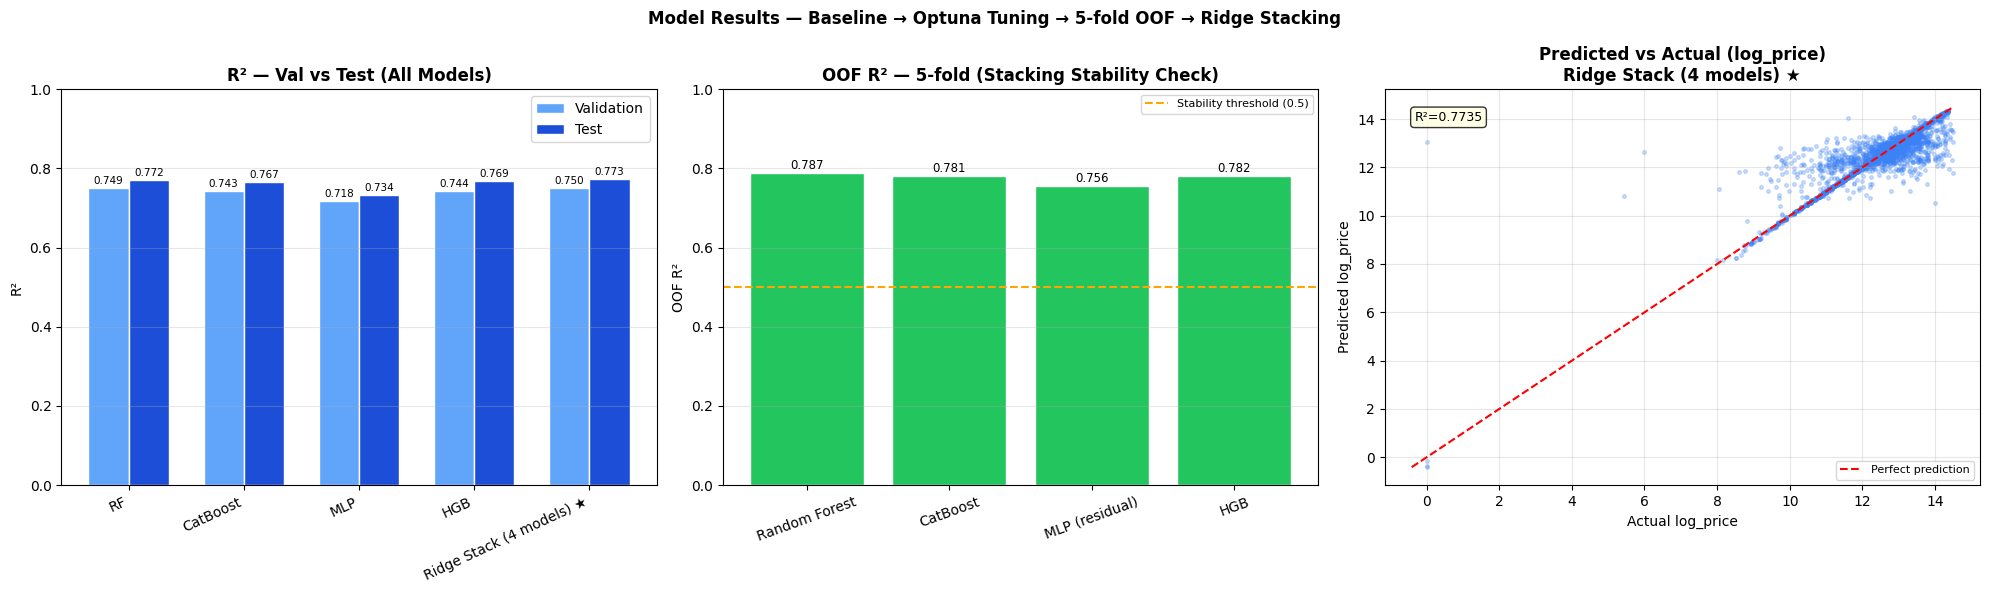

Saved → /content/drive/MyDrive/RealEstate_TXNY/model_results_summary.png

MODELLING PIPELINE COMPLETE
  Best model   : Ridge Stack (4 models) ★
  Best test R² : 0.7735
  Real-$ MAE   : $59,902


In [6]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 28 — RESULTS VISUALIZATION                                 ║
# ╚══════════════════════════════════════════════════════════════════╝

"""
3-panel visualisation:
  Panel 1: R² comparison — all 5 models + stack (val vs test)
  Panel 2: OOF R² per model — shows which models are the most reliable
  Panel 3: Predicted vs Actual (log price) for best model — test set
"""

print("=" * 65)
print("CELL 28 — RESULTS VISUALISATION")
print("=" * 65)

fig_res, axes_r = plt.subplots(1, 3, figsize=(20, 6))

# Panel 1: Val R² vs Test R² for all 5 + stack
ax_r = axes_r[0]
model_labels = [r["model"].replace(" (tuned)","").replace(" (residual,tuned)","")
                for r in final_results]
val_r2_vals  = [r["R2"] for r in results_tuned] + [
    r2_score(y_reg_val, ridge_meta.predict(
        np.column_stack([rf_tuned.predict(Xva_rf),
                         cb_tuned.predict(Xva_rf),
                         *([denorm_y(mlp_tuned.predict(Xva_sc,verbose=0).flatten())] if INCLUDE_MLP_IN_STACK else []),
                         hgb_tuned.predict(Xva_raw)])))]
test_r2_vals = [r["R2"] for r in final_results]
x_pos_r      = np.arange(len(model_labels))
width_r      = 0.35
ax_r.bar(x_pos_r - width_r/2, val_r2_vals[:len(model_labels)],
          width_r, label="Validation", color="#60A5FA", edgecolor="white")
ax_r.bar(x_pos_r + width_r/2, test_r2_vals,
          width_r, label="Test", color="#1D4ED8", edgecolor="white")
ax_r.set_xticks(x_pos_r); ax_r.set_xticklabels(model_labels, rotation=25, ha="right")
ax_r.set_ylabel("R²"); ax_r.set_ylim(0, 1)
ax_r.set_title("R² — Val vs Test (All Models)", fontweight="bold")
ax_r.legend(); ax_r.grid(axis="y", alpha=0.3)
for i, (v, t) in enumerate(zip(val_r2_vals[:len(model_labels)], test_r2_vals)):
    ax_r.text(i - width_r/2, v + 0.01, f"{v:.3f}", ha="center", fontsize=7.5)
    ax_r.text(i + width_r/2, t + 0.01, f"{t:.3f}", ha="center", fontsize=7.5)

# Panel 2: OOF R² per model
ax_oof = axes_r[1]
oof_names_plot = [r["Model"] for r in oof_results]
oof_r2_vals    = [r["OOF R²"] for r in oof_results]
colors_oof = ["#22C55E" if v >= MLP_THRESHOLD else "#EF4444" for v in oof_r2_vals]
bars_oof = ax_oof.bar(oof_names_plot, oof_r2_vals, color=colors_oof, edgecolor="white")
ax_oof.axhline(MLP_THRESHOLD, color="orange", linestyle="--", lw=1.5,
                label=f"Stability threshold ({MLP_THRESHOLD})")
ax_oof.set_title("OOF R² — 5-fold (Stacking Stability Check)", fontweight="bold")
ax_oof.set_ylabel("OOF R²"); ax_oof.set_ylim(0, 1)
ax_oof.legend(fontsize=8); ax_oof.grid(axis="y", alpha=0.3)
ax_oof.tick_params(axis="x", rotation=20)
for bar, v in zip(bars_oof, oof_r2_vals):
    ax_oof.text(bar.get_x() + bar.get_width()/2, v + 0.01,
                 f"{v:.3f}", ha="center", fontsize=8.5)

# Panel 3: Predicted vs Actual for best model
ax_pa = axes_r[2]
best_idx  = final_df["R2"].idxmax()
best_preds = final_results[best_idx]
best_name  = best_preds["model"]
# Get the actual test predictions
preds_lookup = dict(zip(
    ["RF (tuned)","CatBoost (tuned)","MLP (residual,tuned)",
     "HGB (tuned)",
     f"Ridge Stack ({len(oof_names)} models) ★"],
    [p_rf_test, p_cat_test, p_mlp_test, p_hgb_test, p_stk_test]
))
best_p = preds_lookup.get(best_name, p_stk_test)
sample_idx = np.random.choice(len(y_reg_test), min(5000, len(y_reg_test)), replace=False)
y_actual  = y_reg_test.values[sample_idx]
y_pred_p  = best_p[sample_idx]
ax_pa.scatter(y_actual, y_pred_p, alpha=0.25, s=7, color="#3B82F6")
lim = [min(y_actual.min(), y_pred_p.min()), max(y_actual.max(), y_pred_p.max())]
ax_pa.plot(lim, lim, "r--", lw=1.5, label="Perfect prediction")
ax_pa.set_title(f"Predicted vs Actual (log_price)\n{best_name}", fontweight="bold")
ax_pa.set_xlabel("Actual log_price")
ax_pa.set_ylabel("Predicted log_price")
ax_pa.legend(fontsize=8); ax_pa.grid(alpha=0.3)
ax_pa.text(0.05, 0.92, f"R²={best_preds['R2']:.4f}",
            transform=ax_pa.transAxes, fontsize=9,
            bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.8))

plt.suptitle("Model Results — Baseline → Optuna Tuning → 5-fold OOF → Ridge Stacking",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/model_results_summary.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {SAVE_DIR}/model_results_summary.png")

print(f"\n{'='*65}")
print("MODELLING PIPELINE COMPLETE")
print("="*65)
print(f"  Best model   : {best_model['model']}")
print(f"  Best test R² : {best_model['R2']:.4f}")
print(f"  Real-$ MAE   : ${best_model['Real_MAE_USD']:,.0f}")



In [7]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CHECKPOINT — SAVE STATE FOR Notebook 4                          ║
# ╚══════════════════════════════════════════════════════════════════╝

import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "dill", "-q"])
import dill, types, json, os

CKPT_DIR  = f"{SAVE_DIR}/checkpoints"
os.makedirs(CKPT_DIR, exist_ok=True)
CKPT_NAME = "checkpoint_5_to_6"

_keras_models = {}
_state        = {}
_skipped      = []
_reserved     = {"_keras_models", "_state", "_skipped", "_reserved",
                  "_name", "_val", "_path", "CKPT_DIR", "CKPT_NAME"}

for _name, _val in list(globals().items()):
    if _name.startswith("_") or _name in _reserved:
        continue
    try:
        if isinstance(_val, types.ModuleType):
            continue
        if type(_val).__module__.startswith("matplotlib"):
            continue
        if isinstance(_val, tf.keras.Model):
            _path = f"{CKPT_DIR}/{CKPT_NAME}__{_name}.keras"
            _val.save(_path)
            _keras_models[_name] = _path
            continue
        dill.dumps(_val)
        _state[_name] = _val
    except Exception:
        _skipped.append(_name)

with open(f"{CKPT_DIR}/{CKPT_NAME}.pkl", "wb") as f:
    dill.dump(_state, f)
with open(f"{CKPT_DIR}/{CKPT_NAME}_keras.json", "w") as f:
    json.dump(_keras_models, f)

print("=" * 65)
print(f"CHECKPOINT SAVED -> {CKPT_DIR}/{CKPT_NAME}.pkl")
print("=" * 65)
print(f"  Variables saved    : {len(_state)}")
print(f"  Keras models saved : {list(_keras_models.keys()) or 'none'}")
if _skipped:
    print(f"  Skipped (not needed downstream / not picklable): {_skipped}")
print("from its first cell — it will restore this state automatically.")

CHECKPOINT SAVED -> /content/drive/MyDrive/RealEstate_TXNY/checkpoints/checkpoint_5_to_6.pkl
  Variables saved    : 451
  Keras models saved : ['mlp_base_model', 'mlp_tuned', 'mlp_f']
  Skipped (not needed downstream / not picklable): ['get_ipython', 'exit', 'quit']
from its first cell — it will restore this state automatically.
